# Backtest Demo — S&P 500 1B log returns

Same flow as `getting_started/cpi_backtest_demo.ipynb`: **LastValuePredictor**, **DartsAutoARIMAPredictor**, and **DartsChronos2Predictor** (Chronos-2 via Darts; first run downloads weights from Hugging Face). The notebook ends with a **direction (up/down) classification** view of each model’s median sign vs realized sign, plus ROC AUC from quantile-implied `P(up)`.

In [1]:
import os
import sys
from pathlib import Path


def _bootstrap_sys_path() -> Path:
    if os.environ.get("AIENG_REPO_ROOT"):
        root = Path(os.environ["AIENG_REPO_ROOT"]).expanduser().resolve()
        if (root / "aieng-forecasting").is_dir():
            for sub in (root, root / "aieng-forecasting", root / "implementations"):
                s = str(sub)
                if s not in sys.path:
                    sys.path.insert(0, s)
            return root
    seeds: list[Path] = []
    try:
        from IPython import get_ipython  # type: ignore[import-not-found]

        ip = get_ipython()
        if ip is not None:
            nb = ip.user_ns.get("__vsc_ipynb_file__")
            if nb:
                seeds.append(Path(nb).resolve().parent)
    except Exception:
        pass
    for env_key in ("PWD", "INIT_CWD", "OLDPWD"):
        v = os.environ.get(env_key)
        if v:
            try:
                seeds.append(Path(v).expanduser().resolve())
            except (OSError, ValueError):
                pass
    try:
        seeds.append(Path.cwd().resolve())
    except (FileNotFoundError, OSError):
        pass
    for seed in seeds:
        for p in (seed, *seed.parents):
            if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir():
                for sub in (p, p / "aieng-forecasting", p / "implementations"):
                    s = str(sub)
                    if s not in sys.path:
                        sys.path.insert(0, s)
                return p
    raise RuntimeError(
        "Cannot find repo root. Pick the project's .venv kernel, or set AIENG_REPO_ROOT."
    )


REPO_ROOT = _bootstrap_sys_path()

import aieng.forecasting  # noqa: F401
from aieng.forecasting.evaluation import BacktestSpec, backtest

import matplotlib.pyplot as plt
import pandas as pd
import yaml

from experiments.stock_price_forecasting_single_variable.data import (
    SP500_LOG_RETURN_SERIES_ID,
    build_sp500_log_return_service,
)
from methods.darts_arima import DartsAutoARIMAPredictor
from methods.darts_chronos2 import DartsChronos2Predictor
from methods.naive import LastValuePredictor



## 1. Register log-return series

In [2]:
svc = build_sp500_log_return_service(refresh=False, start="2024-09-01")
summary = svc.summary()
summary["start"] = summary["start"].dt.strftime("%Y-%m-%d")
summary["end"] = summary["end"].dt.strftime("%Y-%m-%d")
summary

,series_id,description,source,units,frequency,n_obs,start,end
0,sp500_log_ret_1b,"S&P 500 one-business-day log return, derived f...","Yahoo Finance (^GSPC), derived",log-return,B,407,2024-09-04,2026-04-20


## 2. Load spec

In [3]:
spec_path = REPO_ROOT / "reference_specs" / "sp500_log_return_1b.yaml"
with spec_path.open() as f:
    spec = BacktestSpec.model_validate(yaml.safe_load(f))
print(spec.task.task_id, len(spec.origins()), spec.warmup)

sp500_log_return_1b 121 365


## 3. Predictors

In [12]:
naive_predictor = LastValuePredictor()
arima_predictor = DartsAutoARIMAPredictor(num_samples=500)
# Smaller Chronos-2 variant for faster download/inference; use hub_model_name="amazon/chronos-2" for the full model.
chronos_predictor = DartsChronos2Predictor(hub_model_name="autogluon/chronos-2")

## 4. Run backtests

In [13]:
naive_results = backtest(predictor=naive_predictor, spec=spec, data_service=svc)
arima_results = backtest(predictor=arima_predictor, spec=spec, data_service=svc)
chronos_results = backtest(predictor=chronos_predictor, spec=spec, data_service=svc)
for r in (naive_results, arima_results, chronos_results):
    print(r.predictor_id, len(r.predictions), r.mean_crps)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  7.97it/s]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 60.94it/s]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 34.87it/s]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 37.29it/s]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 31.84it/s]
last_value_naive 40 0.011679154143645683
darts_autoarima 40 0.005980951868470698
darts_chronos2 40 0.005934638227926181


## 5. Per-origin CRPS

In [14]:
def frame(result, label):
    return pd.DataFrame({
        "origin": [p.as_of.date() for p in result.predictions],
        "forecast_date": [p.forecast_date.date() for p in result.predictions],
        f"point_{label}": [p.payload.point_forecast for p in result.predictions],
        f"crps_{label}": result.scores,
    }).set_index("forecast_date")

naive_df = frame(naive_results, "naive")
arima_df = frame(arima_results, "arima")
chronos_df = frame(chronos_results, "chronos2")
comparison = naive_df.join(arima_df[["point_arima", "crps_arima"]], how="inner").join(
    chronos_df[["point_chronos2", "crps_chronos2"]], how="inner"
)
comparison.head(10)

,origin,point_naive,crps_naive,point_arima,crps_arima,point_chronos2,crps_chronos2
forecast_date,,,,,,,
2026-02-20,2026-02-19,0.005551,0.001365,-0.000045,0.004261,0.001320,0.003470
2026-02-23,2026-02-20,-0.002826,0.007614,-0.000524,0.005881,0.001231,0.007678
2026-02-24,2026-02-23,0.006916,0.000707,-0.000239,0.004765,0.001353,0.003896
2026-02-25,2026-02-24,-0.010440,0.018543,-0.000762,0.005260,0.001369,0.004157
2026-02-26,2026-02-25,0.007622,0.013003,0.000827,0.004302,0.001292,0.004194
2026-02-27,2026-02-26,0.008103,0.012452,-0.000860,0.003195,0.001517,0.003639
2026-03-02,2026-02-27,-0.005380,0.005778,-0.000598,0.002793,0.001296,0.001911
2026-03-03,2026-03-02,-0.004349,0.005140,0.000051,0.005572,0.000975,0.006540
2026-03-04,2026-03-03,0.000398,0.007328,0.000208,0.004626,0.001253,0.003991


## 6. Plot

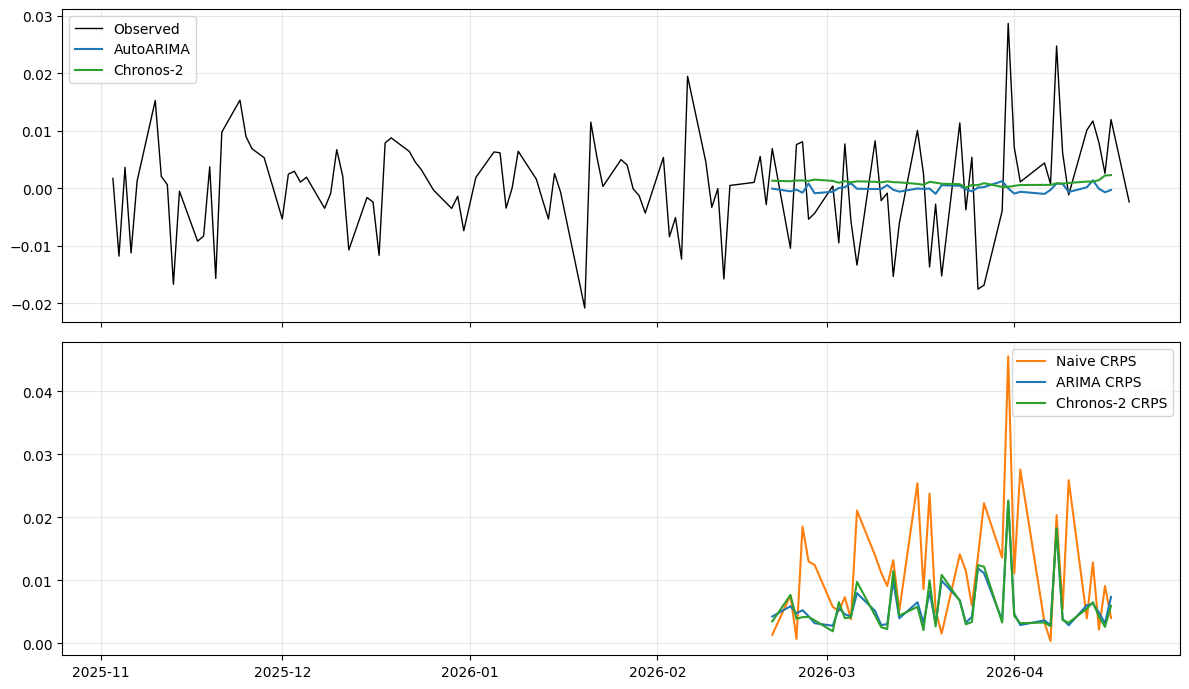

In [15]:
target_df = svc.get_series(SP500_LOG_RETURN_SERIES_ID, as_of=pd.Timestamp("2100-01-01"))
target_df = target_df.set_index("timestamp").sort_index()
win = target_df.loc[pd.Timestamp(spec.start) : pd.Timestamp(spec.end)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(win.index, win["value"], color="black", linewidth=1, label="Observed")
ad = [p.forecast_date for p in arima_results.predictions]
ax1.plot(ad, [p.payload.point_forecast for p in arima_results.predictions], color="tab:blue", label="AutoARIMA")
ax1.plot(ad, [p.payload.point_forecast for p in chronos_results.predictions], color="tab:green", label="Chronos-2")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(ad, naive_results.scores, color="tab:orange", label="Naive CRPS")
ax2.plot(ad, arima_results.scores, color="tab:blue", label="ARIMA CRPS")
ax2.plot(ad, chronos_results.scores, color="tab:green", label="Chronos-2 CRPS")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Direction: will the next log return be up or down?

Treat **sign of the realized one-step log return** as the label: **up** if `actual > 0`, else **down** (including exactly zero as down). Compare that to the **sign of the point forecast** (`point_forecast > 0`) from each model.

We also derive **`prob_up`**, an approximate `P(return > 0)` from the reported forecast quantiles (piecewise-linear CDF through the `(value, quantile)` pairs), and report **ROC AUC** using `prob_up` as a score for the up class.

Metrics include accuracy, balanced accuracy, per-class precision / recall / F1, Matthews correlation, Cohen’s kappa, the 2×2 confusion counts, and simple **majority-class** baselines for context.

In [18]:
from experiments.stock_price_forecasting_single_variable import (
    build_direction_eval_frame,
    direction_classification_metrics,
    direction_classification_report_str,
)

models_direction = {
    "AutoARIMA": arima_results,
    "Chronos-2": chronos_results,
}
dir_rows = []
direction_frames: dict[str, pd.DataFrame] = {}
for label, res in models_direction.items():
    df_dir = build_direction_eval_frame(
        res.predictions,
        target_series_id=spec.task.target_series_id,
        data_service=svc,
    )
    direction_frames[label] = df_dir
    m = direction_classification_metrics(df_dir)
    m.name = label
    dir_rows.append(m)

direction_summary = pd.DataFrame(dir_rows)
direction_summary

,n,prevalence_up,accuracy,balanced_accuracy,precision_up,recall_up,f1_up,precision_down,recall_down,f1_down,matthews_corrcoef,cohen_kappa,confusion_tn,confusion_fp,confusion_fn,confusion_tp,baseline_accuracy_maj_class,baseline_always_predict_up,roc_auc_prob_up
AutoARIMA,40.0,0.55,0.40,0.414141,0.428571,0.272727,0.333333,0.384615,0.555556,0.454545,-0.179106,-0.165049,10.0,8.0,16.0,6.0,0.55,0.55,0.434343
Chronos-2,40.0,0.55,0.55,0.500000,0.550000,1.000000,0.709677,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,18.0,0.0,22.0,0.55,0.55,0.449495


In [19]:
for label, df_dir in direction_frames.items():
    print(f"=== {label} — sklearn classification_report (point forecast sign) ===")
    print(direction_classification_report_str(df_dir))
    print()

=== AutoARIMA — sklearn classification_report (point forecast sign) ===
              precision    recall  f1-score   support

  down (<=0)      0.385     0.556     0.455        18
     up (>0)      0.429     0.273     0.333        22

    accuracy                          0.400        40
   macro avg      0.407     0.414     0.394        40
weighted avg      0.409     0.400     0.388        40


=== Chronos-2 — sklearn classification_report (point forecast sign) ===
              precision    recall  f1-score   support

  down (<=0)      0.000     0.000     0.000        18
     up (>0)      0.550     1.000     0.710        22

    accuracy                          0.550        40
   macro avg      0.275     0.500     0.355        40
weighted avg      0.303     0.550     0.390        40


